In [1]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [2]:
import os

dataset_path = "/kaggle/input/datasets"

print(os.listdir(dataset_path))

['jannatulferdaues']


In [3]:
import os

dataset_path = "/kaggle/input/datasets/jannatulferdaues/aquarium-fish-classification"

print(os.listdir(dataset_path))

['Final (°_°)']


In [4]:
import os

DATASET_PATH = "/kaggle/input/datasets/jannatulferdaues/aquarium-fish-classification/Final (°_°)"

print(os.listdir(DATASET_PATH))

['Guppy', 'Gold', 'Bete', 'Oscar', 'Discuss', 'Cray']


# YoLOv8

⚠️  No train/ subfolder found. Auto-splitting dataset 80/20 …
✅ Split saved to: /content/drive/MyDrive/Croplens/YOLOv8_output/dataset_split
Classes found (6): ['Bete', 'Cray', 'Discuss', 'Gold', 'Guppy', 'Oscar']

Loading pretrained model: yolov8m-cls.pt

========== Phase 1: Training (frozen backbone) ==========
Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Croplens/YOLOv8_output/dataset_split, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=2, half=False, hsv_h=0.0

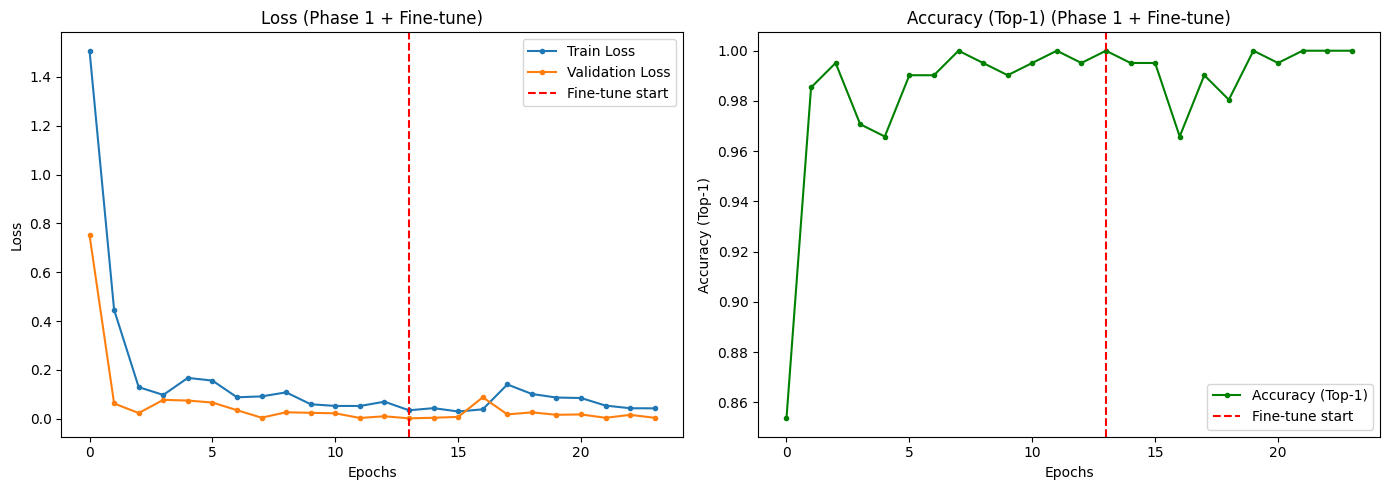

✅ Training curves saved: /content/drive/MyDrive/Croplens/YOLOv8_output/training_curves.png
✅ Confusion matrix found: /content/drive/MyDrive/Croplens/YOLOv8_output/phase2/confusion_matrix.png

Generating sample prediction grid …


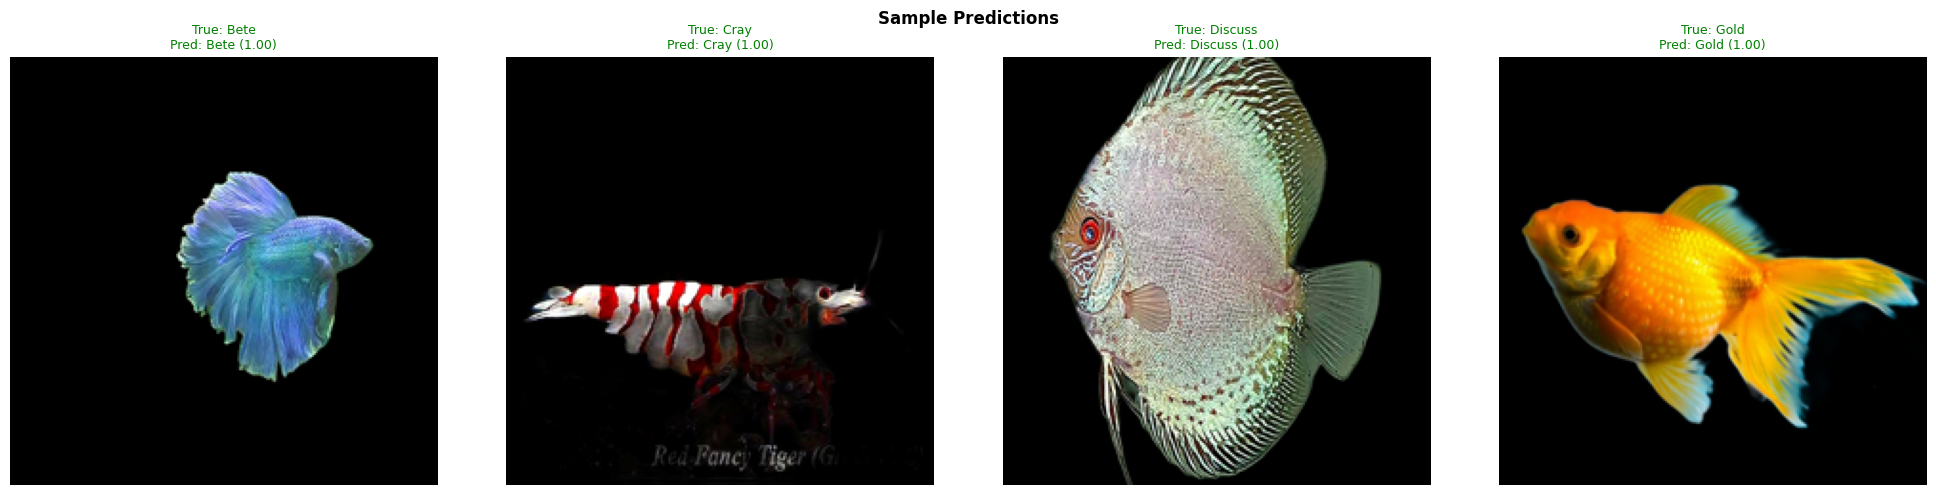

✅ Sample predictions saved: /content/drive/MyDrive/Croplens/YOLOv8_output/sample_predictions.png

Generating Word report …

✅ YOLOv8 (classify) training complete!
📦 Best weights : /content/drive/MyDrive/Croplens/YOLOv8_output/phase2/weights/best.pt
📄 Report       : /content/drive/MyDrive/Croplens/YOLOv8_output/classification_report_yolov8.docx
📁 All outputs  : /content/drive/MyDrive/Croplens/YOLOv8_output


In [6]:
# ==========================================
# YOLOv8 Object Detection / Classification
# Google Colab Version — CropLens Dataset
# ==========================================

# Install dependencies
!pip install ultralytics python-docx seaborn
import os
import shutil
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from docx import Document
from docx.shared import Inches
from ultralytics import YOLO

# ==========================================
# Paths & Parameters
# ==========================================


input_path  = "/kaggle/input/datasets/jannatulferdaues/aquarium-fish-classification/Final (°_°)"
os.makedirs(output_path, exist_ok=True)

# ── Choose task ──────────────────────────────────────────────────────────────
# 'detect'   → bounding-box object detection  (needs YOLO label .txt files)
# 'classify' → image-level classification     (class-folder structure, same as ResNet)
TASK = 'classify'   # ← change to 'detect' if you have bounding-box labels

# ── Model variant ─────────────────────────────────────────────────────────────
# yolov8n  (nano)   – fastest, least accurate
# yolov8s  (small)
# yolov8m  (medium)
# yolov8l  (large)
# yolov8x  (extra-large) – slowest, most accurate
MODEL_VARIANT  = 'yolov8m'          # good balance of speed & accuracy
IMG_SIZE       = 224                # must match your dataset resolution
BATCH_SIZE     = 32
EPOCHS         = 25
LEARNING_RATE  = 0.000001
FINE_TUNE_LR   = LEARNING_RATE / 10
PATIENCE       = 6                  # early-stop patience
WORKERS        = 2                  # dataloader workers (keep ≤2 on Colab)

# ==========================================
# Auto-generate data.yaml (detect mode only)
# ==========================================
def build_data_yaml(dataset_root: str, yaml_path: str) -> list:
    """
    Scans dataset_root/images/train to discover class names,
    writes a YOLO-compatible data.yaml, and returns the class list.
    """
    train_img_dir = os.path.join(dataset_root, "images", "train")
    val_img_dir   = os.path.join(dataset_root, "images", "val")

    # Derive class names from label files (folder names if classification)
    label_dir = os.path.join(dataset_root, "labels", "train")
    # For detection: class IDs in .txt files — discover from directory names
    classes = sorted([
        d for d in os.listdir(train_img_dir)
        if os.path.isdir(os.path.join(train_img_dir, d))
    ]) if os.path.isdir(train_img_dir) else []

    if not classes:
        # Flat structure: infer class count from label files
        txt_files = list(Path(label_dir).glob("*.txt"))
        ids = set()
        for f in txt_files:
            for line in f.read_text().strip().splitlines():
                ids.add(int(line.split()[0]))
        classes = [f"class_{i}" for i in sorted(ids)]

    data = {
        "path": dataset_root,
        "train": "images/train",
        "val":   "images/val",
        "nc":    len(classes),
        "names": classes
    }
    with open(yaml_path, "w") as f:
        yaml.dump(data, f, default_flow_style=False)

    print(f"✅ data.yaml written → {yaml_path}")
    print(f"   Classes ({len(classes)}): {classes}")
    return classes

# ==========================================
# Resolve dataset config based on task
# ==========================================
if TASK == 'classify':
    # Classification: point directly at the class-folder root
    # YOLOv8 classify expects:
    #   Dataset/
    #     train/  class_a/  class_b/ ...
    #     val/    class_a/  class_b/ ...
    data_config = input_path
    model_suffix = '-cls'

    # Auto-detect classes from train split
    train_dir = os.path.join(input_path, "train")
    if not os.path.isdir(train_dir):
        # Flat dataset → split it 80/20 automatically
        print("⚠️  No train/ subfolder found. Auto-splitting dataset 80/20 …")
        split_root = os.path.join(output_path, "dataset_split")
        all_classes = [d for d in os.listdir(input_path)
                       if os.path.isdir(os.path.join(input_path, d))]
        for split in ['train', 'val']:
            for cls in all_classes:
                os.makedirs(os.path.join(split_root, split, cls), exist_ok=True)
        import random
        random.seed(42)
        for cls in all_classes:
            imgs = [f for f in os.listdir(os.path.join(input_path, cls))
                    if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            random.shuffle(imgs)
            split_idx = int(len(imgs) * 0.8)
            for i, img in enumerate(imgs):
                src  = os.path.join(input_path, cls, img)
                dest = os.path.join(split_root,
                                    'train' if i < split_idx else 'val',
                                    cls, img)
                shutil.copy2(src, dest)
        data_config = split_root
        train_dir   = os.path.join(split_root, "train")
        print(f"✅ Split saved to: {split_root}")

    classes = sorted([
        d for d in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, d))
    ])
    print(f"Classes found ({len(classes)}): {classes}")

else:  # detect
    yaml_path   = os.path.join(output_path, "data.yaml")
    classes     = build_data_yaml(input_path, yaml_path)
    data_config = yaml_path
    model_suffix = ''

# ==========================================
# Load YOLOv8 pretrained model
# ==========================================
model_name = f"{MODEL_VARIANT}{model_suffix}.pt"
print(f"\nLoading pretrained model: {model_name}")
model = YOLO(model_name)   # auto-downloads from Ultralytics on first run

# ==========================================
# Phase 1 — Train with frozen backbone
# ==========================================
print("\n========== Phase 1: Training (frozen backbone) ==========")
results_phase1 = model.train(
    data       = data_config,
    task       = TASK,
    epochs     = EPOCHS,
    imgsz      = IMG_SIZE,
    batch      = BATCH_SIZE,
    lr0        = LEARNING_RATE,
    lrf        = 0.01,           # final LR = lr0 * lrf
    patience   = PATIENCE,
    freeze     = 2,             # Corrected: Reduce freeze value to avoid freezing entire model
    workers    = WORKERS,
    project    = output_path,
    name       = "phase1",
    exist_ok   = True,
    plots      = True,           # auto-saves training curves & confusion matrix
    save       = True,
    verbose    = True,
    augment    = True,           # Mosaic, flips, HSV jitter etc.
    cos_lr     = True,           # cosine LR schedule
    seed       = 42
)

phase1_dir = os.path.join(output_path, "phase1")

# ==========================================
# Phase 2 — Fine-tune (unfreeze all layers)
# ==========================================
print("\n========== Phase 2: Fine-tuning (all layers unfrozen) ==========")
best_phase1 = os.path.join(phase1_dir, "weights", "best.pt")
model_ft    = YOLO(best_phase1)   # resume from best Phase 1 checkpoint

results_phase2 = model_ft.train(
    data       = data_config,
    task       = TASK,
    epochs     = 10,
    imgsz      = IMG_SIZE,
    batch      = BATCH_SIZE,
    lr0        = FINE_TUNE_LR,   # much smaller LR — protect pretrained weights
    lrf        = 0.01,
    patience   = PATIENCE,
    freeze     = 0,              # unfreeze entire network
    workers    = WORKERS,
    project    = output_path,
    name       = "phase2",
    exist_ok   = True,
    plots      = True,
    save       = True,
    verbose    = True,
    augment    = True,
    cos_lr     = True,
    seed       = 42
)

phase2_dir  = os.path.join(output_path, "phase2")
best_model  = os.path.join(phase2_dir, "weights", "best.pt")
print(f"\n✅ Best model saved: {best_model}")

# ==========================================
# Load best model & evaluate on validation set
# ==========================================
print("\n========== Evaluating Best Model ==========")
final_model = YOLO(best_model)
val_results = final_model.val(
    data    = data_config,
    imgsz   = IMG_SIZE,
    batch   = BATCH_SIZE,
    workers = WORKERS,
    verbose = True,
    plots   = True,
    project = output_path,
    name    = "evaluation",
    exist_ok= True,
    save_json= True
)

# ── Extract key metrics ───────────────────────────────────────────────────────
if TASK == 'classify':
    top1_acc = float(val_results.top1)   # top-1 accuracy
    top5_acc = float(val_results.top5)   # top-5 accuracy
    val_loss = float(val_results.fitness) if hasattr(val_results, 'fitness') else 0.0
    print(f"Top-1 Accuracy : {top1_acc * 100:.2f}%")
    print(f"Top-5 Accuracy : {top5_acc * 100:.2f}%")
else:
    map50   = float(val_results.box.map50)
    map5095 = float(val_results.box.map)
    print(f"mAP@0.5       : {map50:.4f}")
    print(f"mAP@0.5:0.95  : {map5095:.4f}")

# ==========================================
# Build merged training curve (Phase 1 + Phase 2)
# ==========================================
def load_results_csv(run_dir: str) -> dict:
    """Parse Ultralytics results.csv into a dict of lists."""
    csv_path = os.path.join(run_dir, "results.csv")
    if not os.path.exists(csv_path):
        return {}
    data = {}
    with open(csv_path) as f:
        headers = [h.strip() for h in f.readline().split(",")]
        for h in headers:
            data[h] = []
        for line in f:
            vals = line.strip().split(",")
            for h, v in zip(headers, vals):
                try:
                    data[h].append(float(v))
                except ValueError:
                    data[h].append(0.0)
    return data

r1 = load_results_csv(phase1_dir)
r2 = load_results_csv(phase2_dir)

# Pick metric keys depending on task
if TASK == 'classify':
    train_loss_key = "train/loss"
    val_loss_key   = "val/loss"
    acc_key        = "metrics/accuracy_top1"
    val_acc_key    = "metrics/accuracy_top1"   # same metric, val split
else:
    train_loss_key = "train/box_loss"
    val_loss_key   = "val/box_loss"
    acc_key        = "metrics/mAP50(B)"
    val_acc_key    = "metrics/mAP50(B)"

def merge_key(d1, d2, key):
    return d1.get(key, []) + d2.get(key, [])

merged_train_loss = merge_key(r1, r2, train_loss_key)
merged_val_loss   = merge_key(r1, r2, val_loss_key)
merged_metric     = merge_key(r1, r2, val_acc_key)
phase1_end        = len(r1.get(train_loss_key, []))

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metric_label = "Accuracy (Top-1)" if TASK == 'classify' else "mAP@0.5"

if merged_train_loss:
    axes[0].plot(merged_train_loss, label="Train Loss",      marker='o', markersize=3)
    axes[0].plot(merged_val_loss,   label="Validation Loss", marker='o', markersize=3)
    axes[0].axvline(x=phase1_end - 1, color='red', linestyle='--', label='Fine-tune start')
axes[0].set_title("Loss (Phase 1 + Fine-tune)")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()

if merged_metric:
    axes[1].plot(merged_metric, label=metric_label, marker='o', markersize=3, color='green')
    axes[1].axvline(x=phase1_end - 1, color='red', linestyle='--', label='Fine-tune start')
axes[1].set_title(f"{metric_label} (Phase 1 + Fine-tune)")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel(metric_label)
axes[1].legend()

plt.tight_layout()
curve_path = os.path.join(output_path, "training_curves.png")
plt.savefig(curve_path, dpi=150)
plt.show()
plt.close()
print(f"✅ Training curves saved: {curve_path}")

# ==========================================
# Confusion Matrix
# ==========================================
# Ultralytics auto-saves confusion_matrix.png — we use that.
# If it exists, copy it to our output root for the report.
auto_cm_paths = [
    os.path.join(phase2_dir, "confusion_matrix.png"),
    os.path.join(phase2_dir, "confusion_matrix_normalized.png"),
    os.path.join(output_path, "evaluation", "confusion_matrix.png"),
]
cm_path = None
for p in auto_cm_paths:
    if os.path.exists(p):
        cm_path = p
        break

# Fallback: generate confusion matrix manually via predictions
if cm_path is None:
    print("Generating confusion matrix manually …")
    val_img_dir = (os.path.join(data_config, "val")
                   if TASK == 'classify'
                   else os.path.join(input_path, "images", "val"))

    y_true, y_pred = [], []
    for cls_idx, cls_name in enumerate(classes):
        cls_dir = os.path.join(val_img_dir, cls_name)
        if not os.path.isdir(cls_dir):
            continue
        imgs = [f for f in os.listdir(cls_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        for img_file in imgs:
            img_path = os.path.join(cls_dir, img_file)
            res      = final_model.predict(img_path, verbose=False)
            pred_cls = int(res[0].probs.top1) if TASK == 'classify' else 0
            y_true.append(cls_idx)
            y_pred.append(pred_cls)

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(max(10, len(classes)), max(8, len(classes) - 2)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix — YOLOv8 ({TASK})')
    plt.tight_layout()
    cm_path = os.path.join(output_path, "confusion_matrix.png")
    plt.savefig(cm_path, dpi=150)
    plt.show()
    plt.close()

    # Build text classification report
    cls_report = classification_report(y_true, y_pred, target_names=classes)
    print("\nClassification Report:\n", cls_report)
else:
    cls_report = "(See confusion matrix image — generated by Ultralytics validator)"
    print(f"✅ Confusion matrix found: {cm_path}")

# ==========================================
# Sample Predictions Visualization
# ==========================================
print("\nGenerating sample prediction grid …")
val_img_dir = (os.path.join(data_config, "val")
               if TASK == 'classify'
               else os.path.join(input_path, "images", "val"))

sample_imgs = []
for cls_name in classes[:min(4, len(classes))]:
    cls_dir = os.path.join(val_img_dir, cls_name)
    if not os.path.isdir(cls_dir):
        continue
    imgs = [f for f in os.listdir(cls_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if imgs:
        sample_imgs.append((os.path.join(cls_dir, imgs[0]), cls_name))

if sample_imgs:
    n = len(sample_imgs)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, (img_path, true_label) in zip(axes, sample_imgs):
        res = final_model.predict(img_path, verbose=False)
        img = Image.open(img_path).resize((IMG_SIZE, IMG_SIZE))
        ax.imshow(img)
        ax.axis('off')
        if TASK == 'classify':
            pred_idx  = int(res[0].probs.top1)
            pred_name = classes[pred_idx] if pred_idx < len(classes) else str(pred_idx)
            conf      = float(res[0].probs.top1conf)
            color     = 'green' if pred_name == true_label else 'red'
            ax.set_title(f"True: {true_label}\nPred: {pred_name} ({conf:.2f})",
                         color=color, fontsize=9)
        else:
            for box in res[0].boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                scale_x = IMG_SIZE / img.width
                scale_y = IMG_SIZE / img.height
                rect = patches.Rectangle(
                    (x1 * scale_x, y1 * scale_y),
                    (x2 - x1) * scale_x, (y2 - y1) * scale_y,
                    linewidth=2, edgecolor='lime', facecolor='none'
                )
                ax.add_patch(rect)
                cls_id = int(box.cls[0])
                conf   = float(box.conf[0])
                label  = f"{classes[cls_id] if cls_id < len(classes) else cls_id} {conf:.2f}"
                ax.text(x1 * scale_x, y1 * scale_y - 5, label,
                        color='lime', fontsize=7, backgroundcolor='black')
            ax.set_title(f"True: {true_label}", fontsize=9)
    plt.suptitle("Sample Predictions", fontsize=12, fontweight='bold')
    plt.tight_layout()
    sample_path = os.path.join(output_path, "sample_predictions.png")
    plt.savefig(sample_path, dpi=150)
    plt.show()
    plt.close()
    print(f"✅ Sample predictions saved: {sample_path}")
else:
    sample_path = None
    print("⚠️  No sample images found for prediction grid.")

# ==========================================
# Word Report
# ==========================================
print("\nGenerating Word report …")
doc = Document()
doc.add_heading(f'Classification Report — YOLOv8 ({TASK.title()}) — CropLens', 0)

# ── Config ────────────────────────────────────────────────────────────────────
doc.add_heading('Dataset & Training Configuration', level=1)
cfg_items = [
    ("Dataset path",          input_path),
    ("Task",                  TASK),
    ("Model variant",         model_name),
    ("Image size",            f"{IMG_SIZE} × {IMG_SIZE}"),
    ("Batch size",            str(BATCH_SIZE)),
    ("Phase 1 epochs",        str(EPOCHS)),
    ("Phase 2 epochs",        "10"),
    ("Base learning rate",    str(LEARNING_RATE)),
    ("Fine-tune LR",          str(FINE_TUNE_LR)),
    ("Early-stop patience",   str(PATIENCE)),
    ("Classes",               ", ".join(classes)),
    ("Total classes",         str(len(classes))),
]
for key, val in cfg_items:
    doc.add_paragraph(f"{key}: {val}")

# ── Performance ───────────────────────────────────────────────────────────────
doc.add_heading('Model Performance', level=1)
if TASK == 'classify':
    doc.add_paragraph(f"Top-1 Validation Accuracy : {top1_acc * 100:.2f}%")
    doc.add_paragraph(f"Top-5 Validation Accuracy : {top5_acc * 100:.2f}%")
else:
    doc.add_paragraph(f"mAP@0.5       : {map50:.4f}")
    doc.add_paragraph(f"mAP@0.5:0.95  : {map5095:.4f}")

# ── Metrics ───────────────────────────────────────────────────────────────────
doc.add_heading('Per-Class Classification Metrics', level=1)
doc.add_paragraph(cls_report)

# ── Curves ────────────────────────────────────────────────────────────────────
doc.add_heading('Training History', level=1)
doc.add_paragraph(
    "Red dashed line marks the transition from Phase 1 (frozen backbone) "
    "to Phase 2 (full fine-tuning)."
)
if os.path.exists(curve_path):
    doc.add_picture(curve_path, width=Inches(6))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
doc.add_heading('Confusion Matrix', level=1)
if cm_path and os.path.exists(cm_path):
    doc.add_picture(cm_path, width=Inches(6))

# ── Sample predictions ────────────────────────────────────────────────────────
if sample_path and os.path.exists(sample_path):
    doc.add_heading('Sample Predictions', level=1)
    doc.add_picture(sample_path, width=Inches(6))

report_path = os.path.join(output_path, 'classification_report_yolov8.docx')
doc.save(report_path)

print(f"\n{'=' * 55}")
print(f"✅ YOLOv8 ({TASK}) training complete!")
print(f"📦 Best weights : {best_model}")
print(f"📄 Report       : {report_path}")
print(f"📁 All outputs  : {output_path}")
print(f"{'=' * 55}")
